In [24]:
#from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate,PromptTemplate
from langchain_core.output_parsers import StrOutputParser
import streamlit as st 
import os 
import sys
sys.path.insert(1, r'D:\Notebooks\LLM\env')
from enviorment import load_env
import os 
from langchain_google_genai import ChatGoogleGenerativeAI
load_env()
from langchain_community.tools.tavily_search import TavilySearchResults
from typing import TypedDict,Annotated,Literal
from pydantic import BaseModel, Field
import operator
from langgraph.graph import StateGraph,START, END,MessagesState

from langgraph.types import Command
from langgraph.checkpoint.memory import InMemorySaver

In [3]:
model=ChatGoogleGenerativeAI(
    model="gemini-2.5-flash-lite",   # or gemini-2.0-pro, 1.5-pro, etc.
    temperature=0.2
)

In [5]:
model.invoke("what is AI").content

'AI stands for **Artificial Intelligence**.\n\nIn its simplest terms, AI refers to the **simulation of human intelligence in machines that are programmed to think and learn like humans.**\n\nThis means creating systems that can:\n\n*   **Perceive:** Understand and interpret information from their environment (e.g., seeing images, hearing sounds, reading text).\n*   **Reason:** Use logic and knowledge to draw conclusions and make decisions.\n*   **Learn:** Improve their performance over time based on new data and experiences, without being explicitly programmed for every single scenario.\n*   **Problem-solve:** Find solutions to complex challenges.\n*   **Act:** Take actions based on their understanding and decisions.\n\n**Think of it as building "smart" machines.** These machines can perform tasks that typically require human intelligence.\n\n**Here\'s a breakdown of key aspects and concepts related to AI:**\n\n*   **Machine Learning (ML):** A subfield of AI that focuses on enabling sy

In [8]:
def call_model(state:MessagesState):
    msg=state["messages"]
    response =model.invoke(msg)
    return {"messages":[response]}

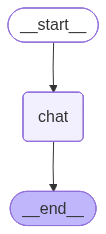

In [25]:
graph=StateGraph(MessagesState)
checkpointer=InMemorySaver()
graph.add_node('chat',call_model)
graph.add_edge(START,'chat')
graph.add_edge('chat',END)
workflow=graph.compile(checkpointer=checkpointer)
workflow

In [19]:
MessagesState

langgraph.graph.message.MessagesState

In [29]:
initial_stage={'messages':[{'role':'human','content':'my name is dharmendra'}]}
thread = {"configurable": {"thread_id": "1"}}
workflow.invoke(initial_stage,config=thread)

{'messages': [HumanMessage(content='I love play football', additional_kwargs={}, response_metadata={}, id='7af94693-414a-44fa-b2cb-e782859993c3'),
  AIMessage(content="That's fantastic! Football is a great sport. What do you love about it?\n\nAre you a player, a fan, or both?\n\nIf you play, what position do you play? What do you enjoy most about being on the field?\n\nIf you're a fan, what team do you support? What do you love about watching the game?\n\nTell me more about your passion for football!", additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--2792e1ad-4b42-4c85-b918-8f67807a0394-0', usage_metadata={'input_tokens': 5, 'output_tokens': 85, 'total_tokens': 90, 'input_token_details': {'cache_read': 0}}),
  HumanMessage(content='what i love playing', additional_kwargs={}, response_metadata={}, id='d

In [31]:
initial_stage={'messages':[{'role':'user','content':'whats my name'}]}
thread = {"configurable": {"thread_id": "1"}}
result=workflow.invoke(initial_stage,config=thread)

In [32]:
for i in result["messages"]:
    i.pretty_print()

================================ Human Message =================================

I love play football
================================== Ai Message ==================================

That's fantastic! Football is a great sport. What do you love about it?

Are you a player, a fan, or both?

If you play, what position do you play? What do you enjoy most about being on the field?

If you're a fan, what team do you support? What do you love about watching the game?

Tell me more about your passion for football!
================================ Human Message =================================

what i love playing
================================== Ai Message ==================================

Ah, so you love **playing** football! That's awesome!

What specifically do you love about playing? Is it:

*   **The physical challenge?** Running, tackling, kicking, the adrenaline rush?
*   **The teamwork and camaraderie?** Working with your teammates, building strategies, celebrating together?
* 